# 3.16 Whale Shark Interpretability
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ada-carter/cv/blob/main/book/Whale_Shark_Interpretability.ipynb)



## Overview

Model interpretability asks not just what a model predicts, but why. GradCAM (Gradient-weighted Class Activation Mapping) highlights the image regions that most influenced a classification decision by computing gradients of the class score with respect to the final convolutional feature map. For whale shark photo-ID, this reveals whether the model attends to the animal's distinctive spot pattern rather than background water or boat artefacts.

The Wild Me whale shark dataset contains annotated images of individual animals identified by their unique spot patterns, which function like fingerprints. We train a ResNet18 classifier to recognize the top 5 most-photographed individuals, then apply GradCAM to inspect which image regions drive each prediction.

### Learning Objectives

By the end of this lesson you will be able to:

1. Load and parse a Wild Me COCO annotation file to extract individual identity labels.
2. Fine-tune a pretrained ResNet18 classifier on a small marine photo-ID dataset.
3. Apply GradCAM to visualize which image regions drive each classification.
4. Critically evaluate whether model attention aligns with biologically meaningful features.


### Dataset: Wild Me Whale Shark Archive

The Wild Me whale shark COCO dataset is hosted on LILA BC (Labeled Information Library of Alexandria: Biology and Conservation). It contains thousands of images of individual whale sharks photographed across multiple field sites, with each animal identified by its unique spot pattern on the flank behind the gills.

The COCO annotation format stores data as a JSON file with three top-level lists: `images` (file paths and IDs), `annotations` (bounding boxes and identity labels), and `categories` (class definitions). Here, the `name` field in each annotation entry stores the individual whale shark's string identifier rather than a numeric category, so we extract it directly.


In [1]:
import os
import urllib.request
import tarfile

dataset_url = "https://storage.googleapis.com/public-datasets-lila/wild-me/whaleshark.coco.tar.gz"
tar_path = "whaleshark.coco.tar.gz"
extract_dir = "whaleshark_data"

if not os.path.exists(tar_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, tar_path)
    print("Download complete.")

if not os.path.exists(extract_dir):
    print("Extracting dataset...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=extract_dir)
    print("Extraction complete.")

Download complete.
Extracting dataset...


/tmp/ipykernel_1458/1007797648.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Extraction complete.


### Loading Annotations and Building the Dataset

We parse the COCO JSON to build a mapping from image_id to individual name, then construct a PyTorch Dataset that loads each image, applies a standard ImageNet normalization transform, and returns the image tensor plus the label index. We restrict to the top 5 most-photographed individuals to keep the dataset manageable and the class balance reasonable.


In [8]:
import os
import json
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Load COCO annotations
anno_file = os.path.join(extract_dir, "whaleshark.coco", "annotations", "instances_train2020.json")
with open(anno_file, 'r') as f:
    coco = json.load(f)

# 1. Map image IDs to their individual string names instead of category_id
image_id_to_name = {}
for ann in coco['annotations']:
    # Grab the string identity field (typically 'name' or 'individual_id' in Wild Me exports)
    individual_name = ann.get('name')
    if individual_name:
        image_id_to_name[ann['image_id']] = individual_name

# 2. Find the top 5 most common individual whale sharks by string name
name_counts = Counter(image_id_to_name.values())
top_classes = [c[0] for c in name_counts.most_common(5)]

# 3. Build our dataset list mapping names to numeric indices
dataset_items = []
for img in coco['images']:
    img_id = img['id']
    if img_id in image_id_to_name:
        individual_name = image_id_to_name[img_id]
        if individual_name in top_classes:
            # Construct path matching your filesystem location
            img_path = os.path.join(extract_dir, "whaleshark.coco", "images", "train2020", img['file_name'])

            # Double check file exists to prevent downstream FileNotFoundError
            if os.path.exists(img_path):
                dataset_items.append({
                    'path': img_path,
                    'label': top_classes.index(individual_name)  # Converts string name into 0-4 numeric label
                })

class WhaleSharkDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        img = Image.open(item['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, item['label']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = WhaleSharkDataset(dataset_items, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
print(f"Created dataset with {len(dataset)} images across {len(top_classes)} individual whale sharks.")
print(f"Top 5 individuals being classified: {top_classes}")

Created dataset with 678 images across 5 individual whale sharks.
Top 5 individuals being classified: ['341569f2-1f34-4884-1dd3-79137be4c77f', 'a785af89-b8c0-5e7b-acec-c4874ec5483f', '24e404dd-094c-e5bd-defa-e52125422443', '21027863-1d99-20d5-e7f9-dd3f7ad3b166', '26560de1-6930-ddaf-5069-f7b85acd40fb']


### Training the Classifier

We fine-tune ResNet18 pre-trained on ImageNet. The final fully connected layer is replaced with a fresh 5-class output head sized for our individual count. The model trains for 30 epochs with the Adam optimizer and cross-entropy loss. On a Colab T4 GPU this takes approximately 5 to 10 minutes. On CPU, plan for significantly longer.

The key transfer learning insight: ImageNet pre-training gives the model strong low-level feature detectors (edges, textures, color gradients). Fine-tuning on whale shark images redirects those detectors toward the spot pattern, fin shape, and body markings that distinguish individuals.


In [14]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Replace final layer for our 5 classes
model.fc = nn.Linear(model.fc.in_features, 5)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30
print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(dataloader):.4f}")
print("Training complete.")

Starting training...
Epoch 1/30 - Loss: 1.7029
Epoch 2/30 - Loss: 1.3642
Epoch 3/30 - Loss: 1.3048
Epoch 4/30 - Loss: 1.1987
Epoch 5/30 - Loss: 0.9746
Epoch 6/30 - Loss: 0.9277
Epoch 7/30 - Loss: 0.8428
Epoch 8/30 - Loss: 0.6293
Epoch 9/30 - Loss: 0.6125
Epoch 10/30 - Loss: 0.4083
Epoch 11/30 - Loss: 0.5477
Epoch 12/30 - Loss: 0.3892
Epoch 13/30 - Loss: 0.3364
Epoch 14/30 - Loss: 0.2693
Epoch 15/30 - Loss: 0.1908
Epoch 16/30 - Loss: 0.3070
Epoch 17/30 - Loss: 0.2449
Epoch 18/30 - Loss: 0.2288
Epoch 19/30 - Loss: 0.1971
Epoch 20/30 - Loss: 0.1876
Epoch 21/30 - Loss: 0.1744
Epoch 22/30 - Loss: 0.0899
Epoch 23/30 - Loss: 0.0791
Epoch 24/30 - Loss: 0.0795
Epoch 25/30 - Loss: 0.0628
Epoch 26/30 - Loss: 0.0873
Epoch 27/30 - Loss: 0.0754
Epoch 28/30 - Loss: 0.0613
Epoch 29/30 - Loss: 0.0717
Epoch 30/30 - Loss: 0.0524
Training complete.


### GradCAM Interpretability Analysis

GradCAM works through five steps:

1. Select a target class (e.g., individual whale shark number 3).
2. Compute the gradient of that class score with respect to the activations of the final convolutional layer (layer4 in ResNet18).
3. Global average pool those gradients to produce per-channel importance weights.
4. Compute a weighted sum of the feature maps using those weights.
5. Apply ReLU to keep only positive activations (regions that support the predicted class).

The resulting heatmap is resized to the input image dimensions and overlaid using `show_cam_on_image()`. Red regions indicate strong positive influence on the prediction; blue regions indicate low or negative influence.

We target `model.layer4[-1]` because it is the deepest convolutional block, producing the most semantically meaningful (but spatially coarsest) feature maps before the global average pool.



Visualizing Grad-CAM for individual: 341569f2-1f34-4884-1dd3-79137be4c77f


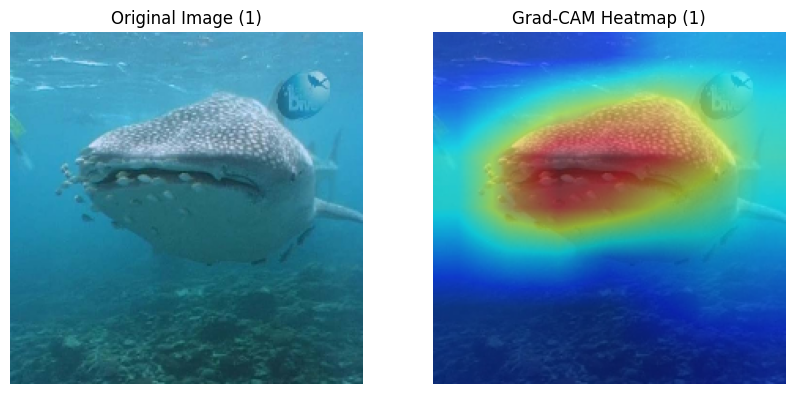

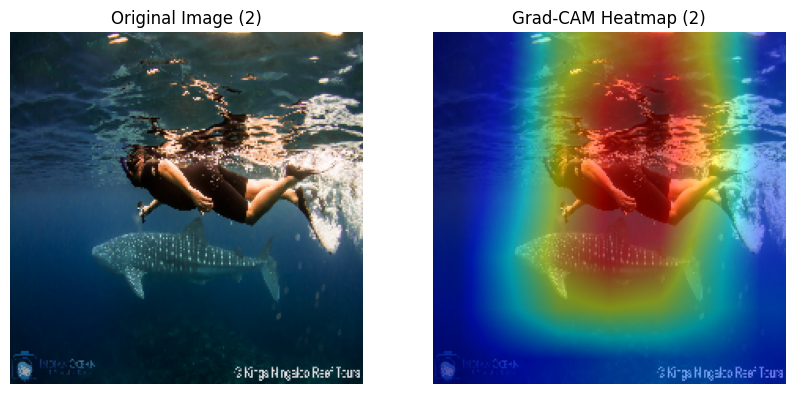

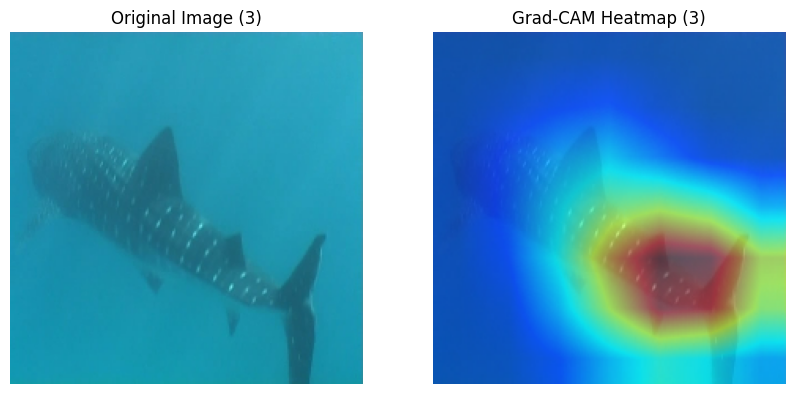

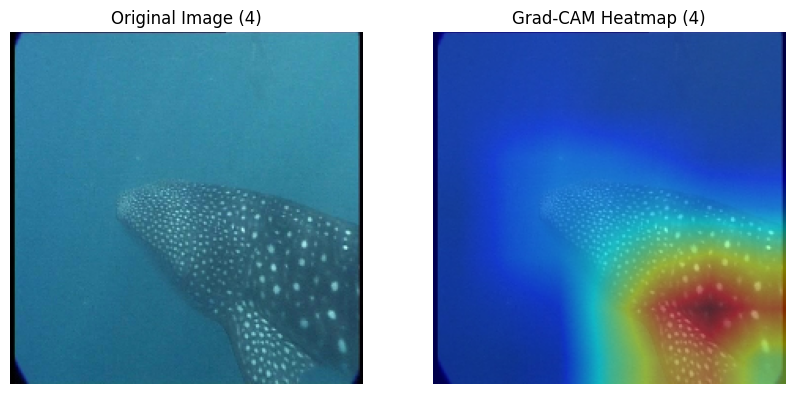

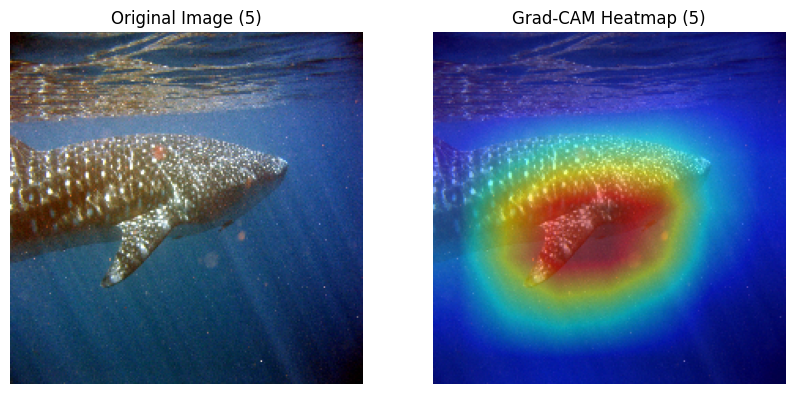

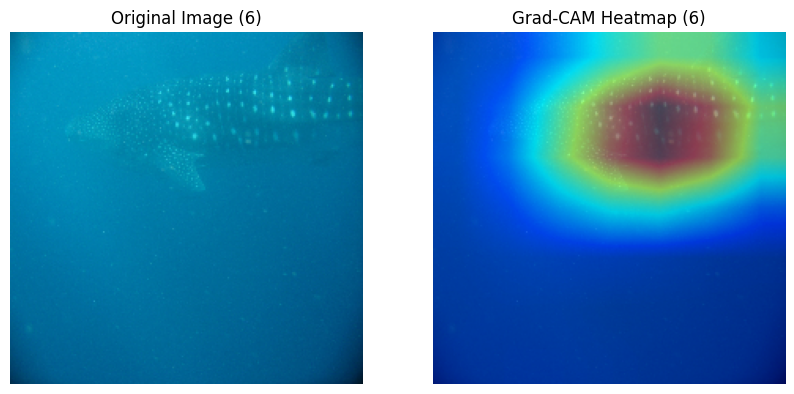

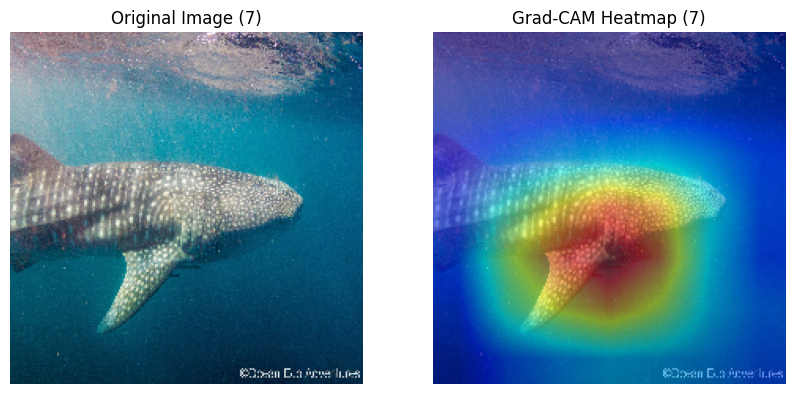

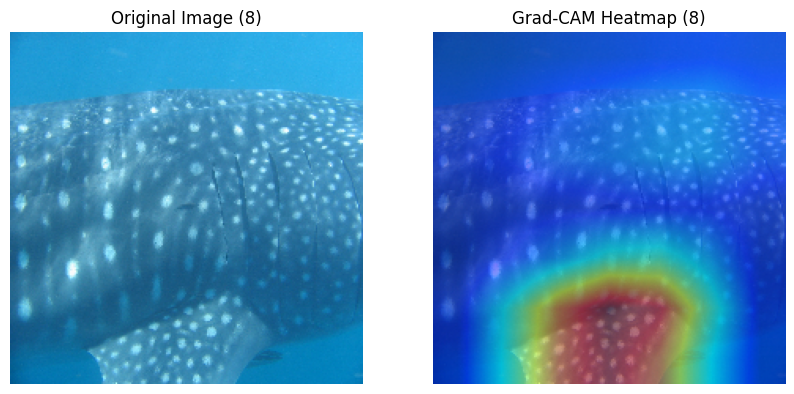

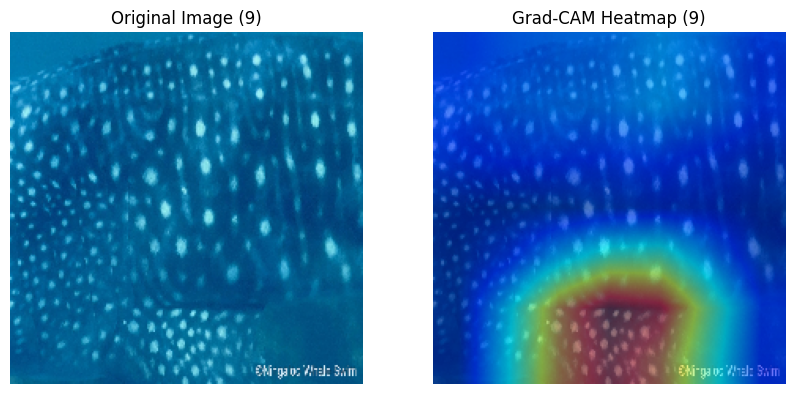

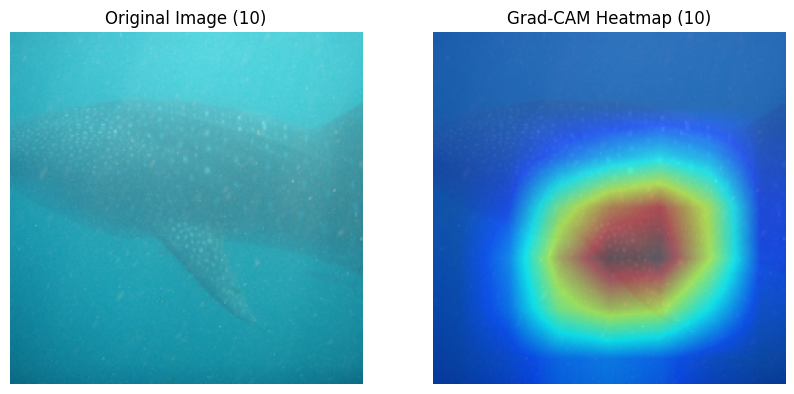


Visualizing Grad-CAM for individual: a785af89-b8c0-5e7b-acec-c4874ec5483f


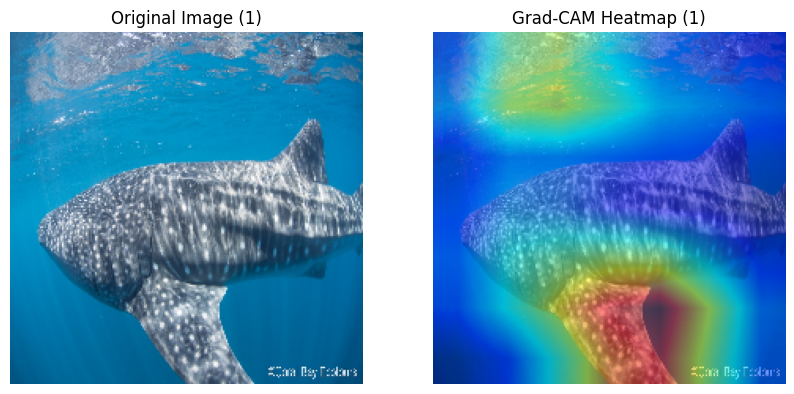

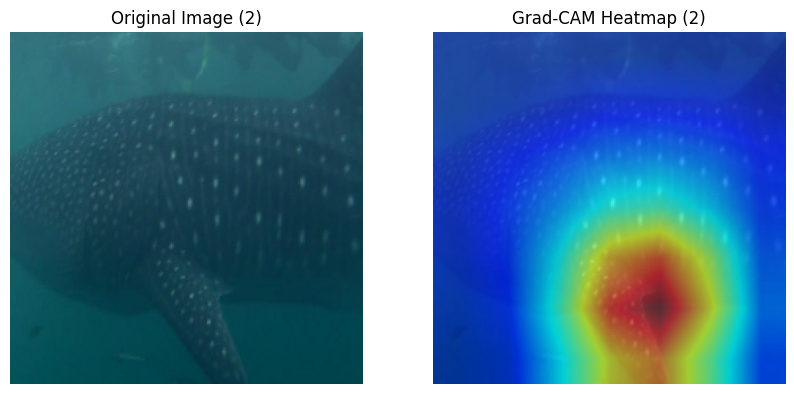

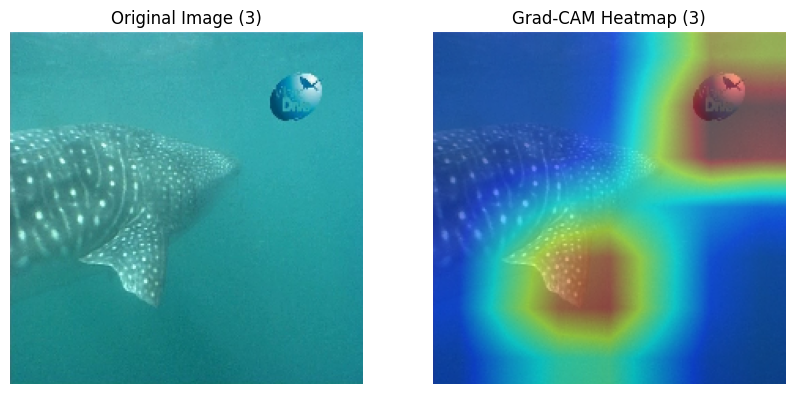

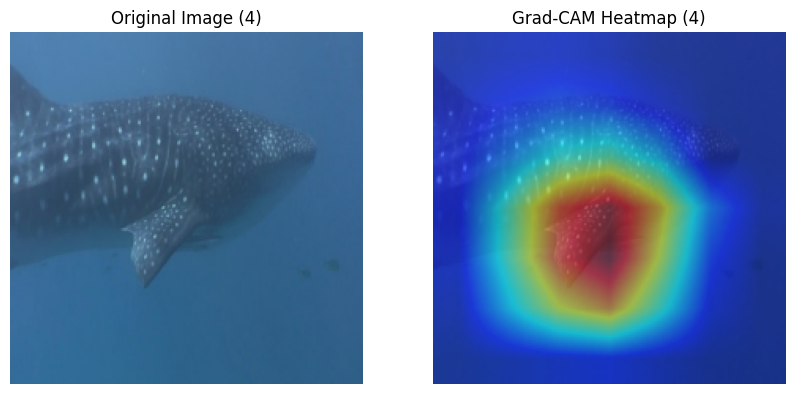

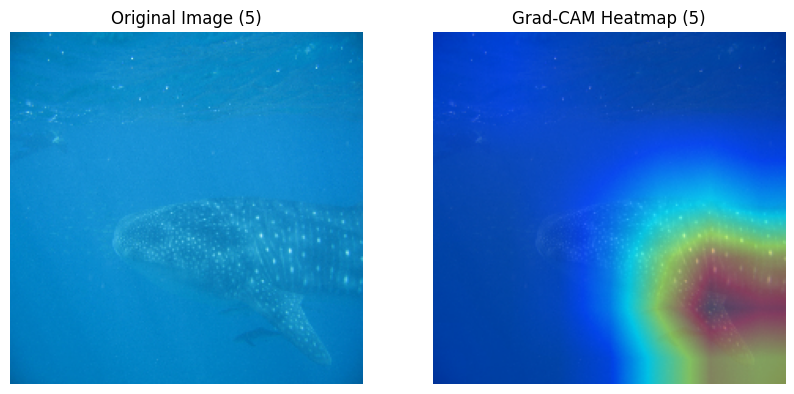

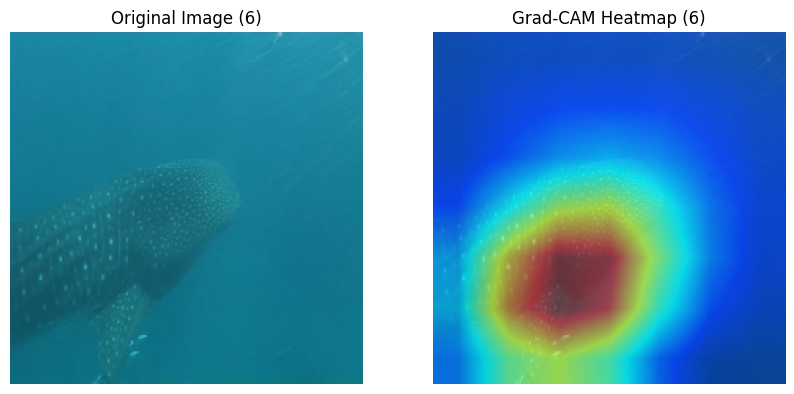

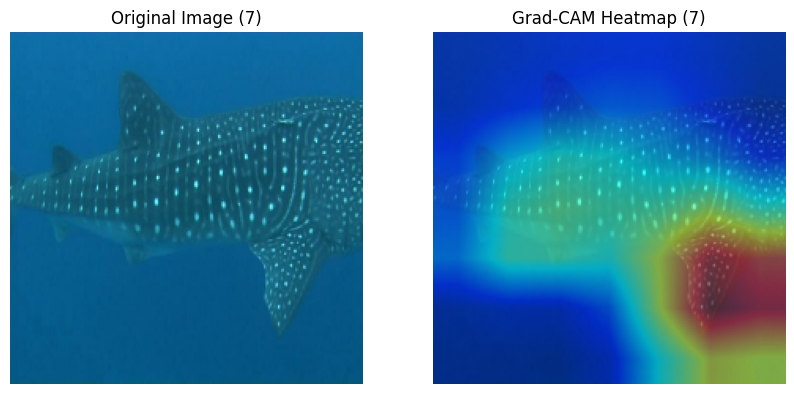

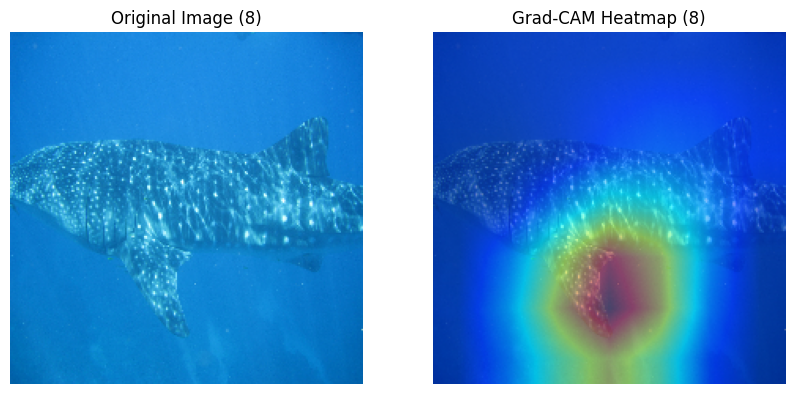

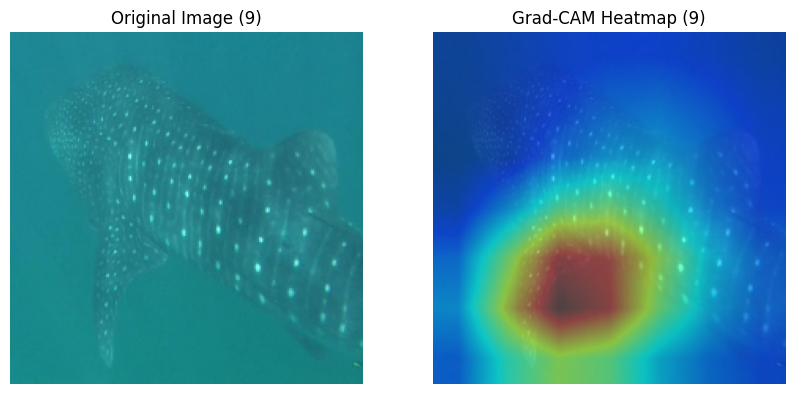

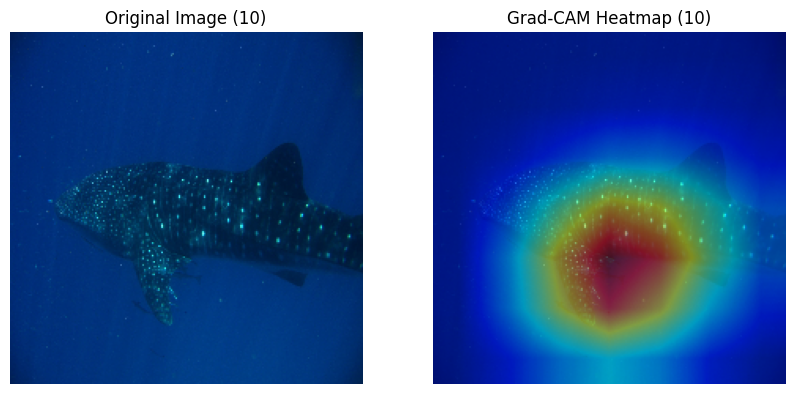


Visualizing Grad-CAM for individual: 24e404dd-094c-e5bd-defa-e52125422443


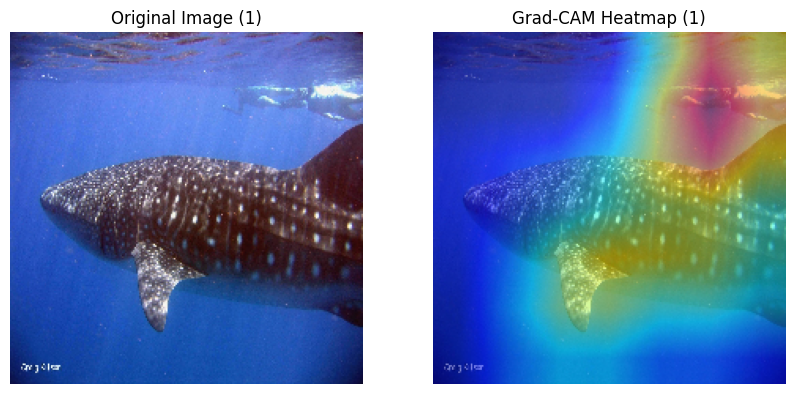

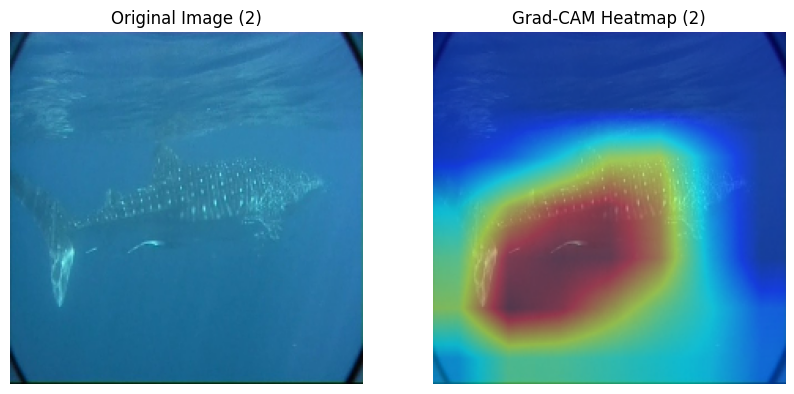

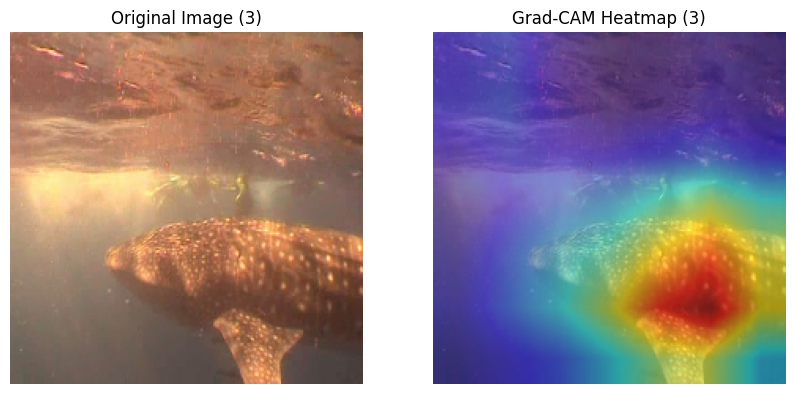

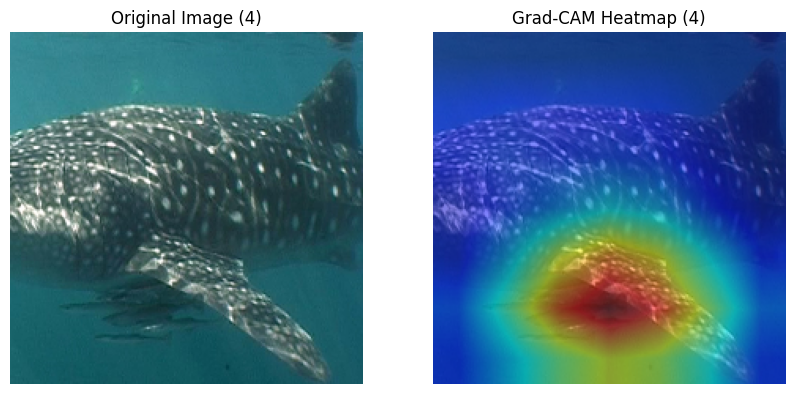

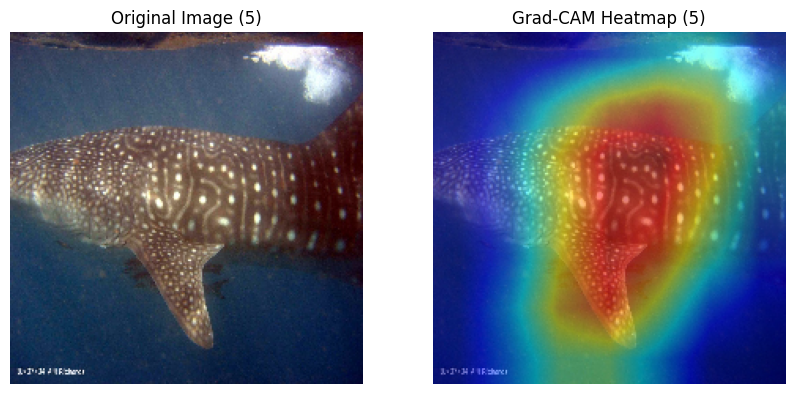

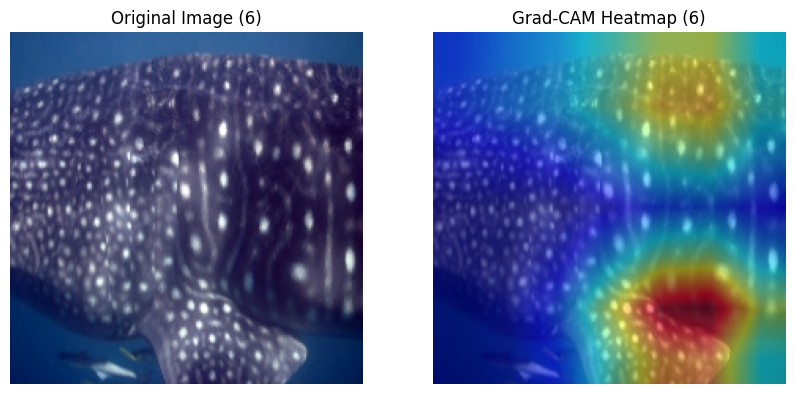

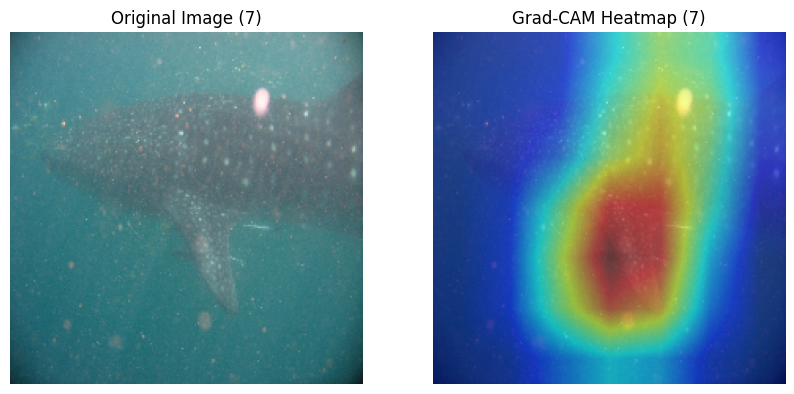

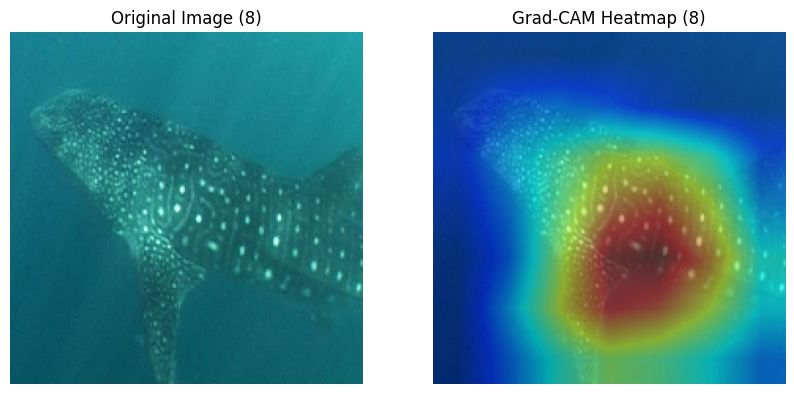

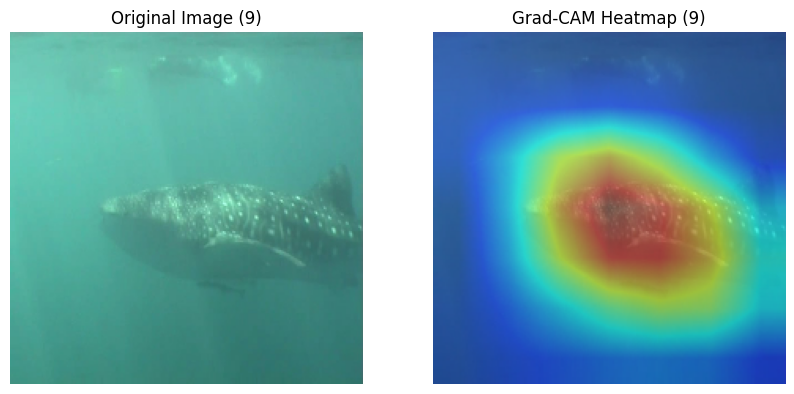

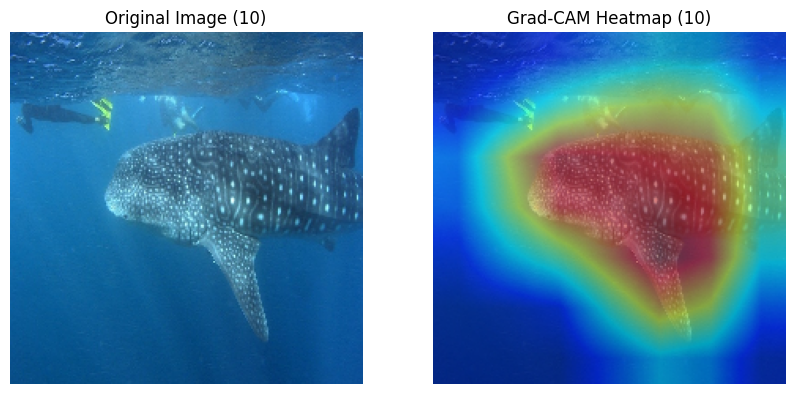


Visualizing Grad-CAM for individual: 21027863-1d99-20d5-e7f9-dd3f7ad3b166


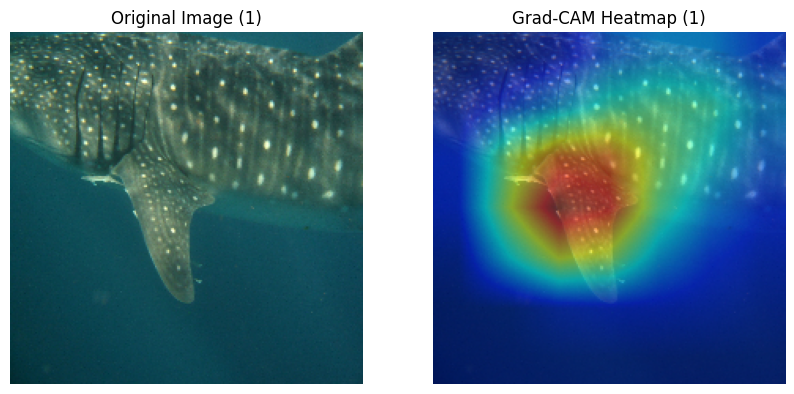

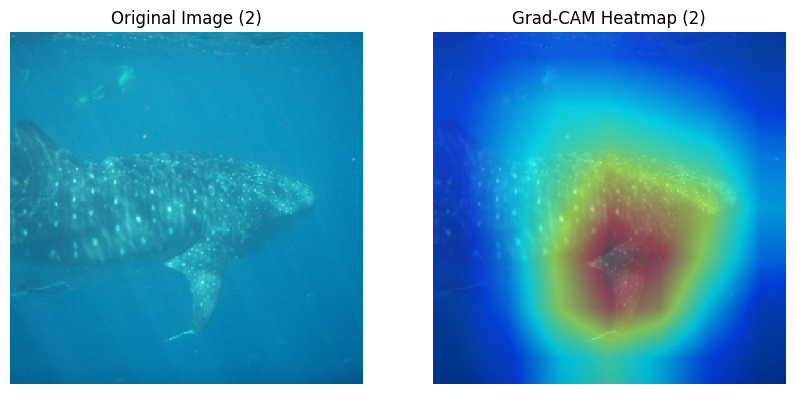

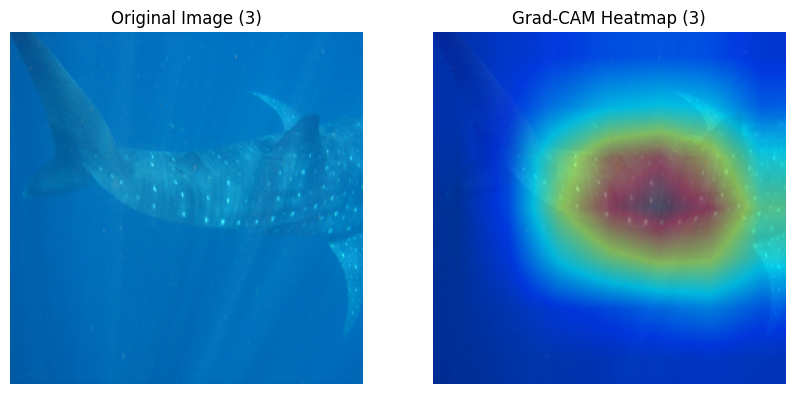

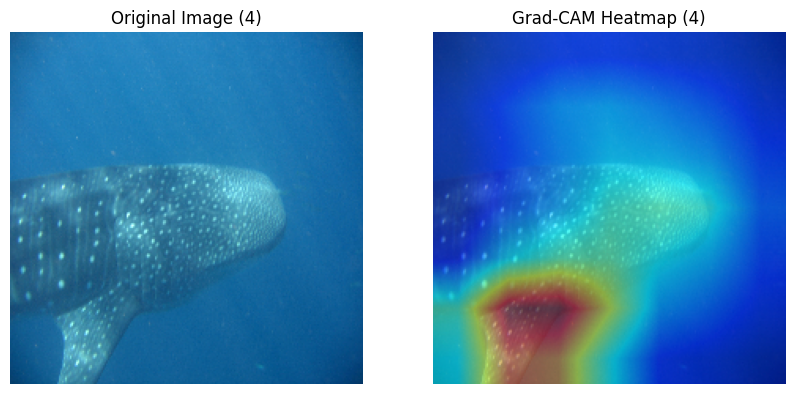

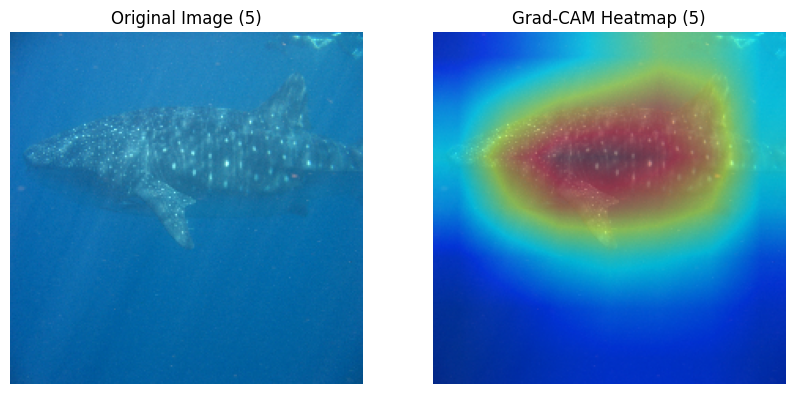

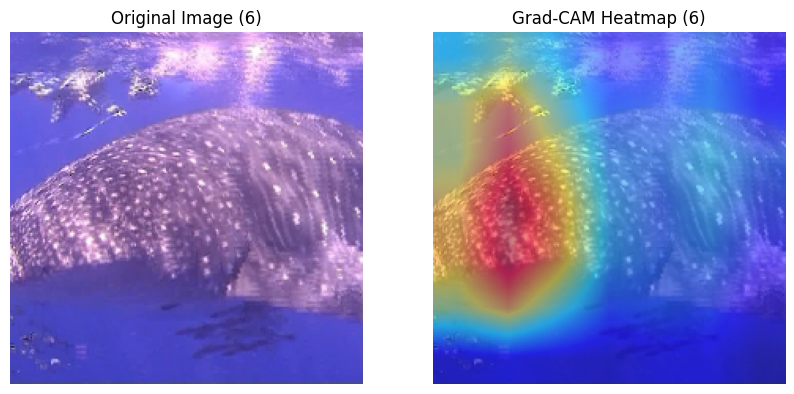

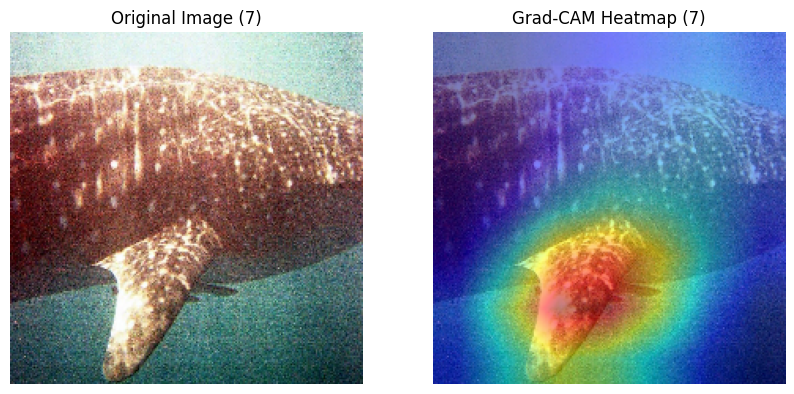

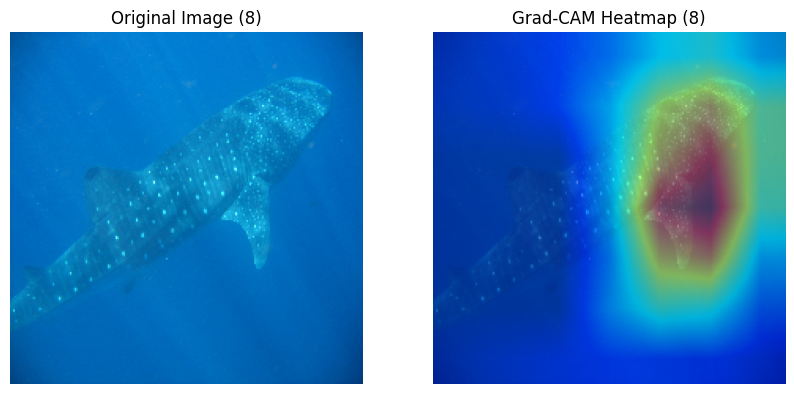

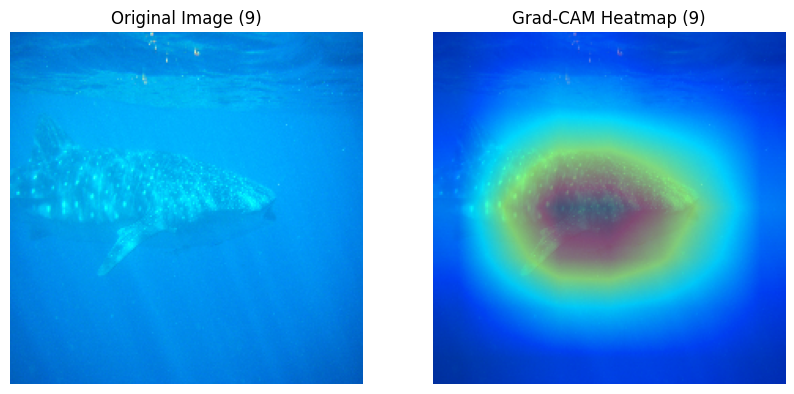

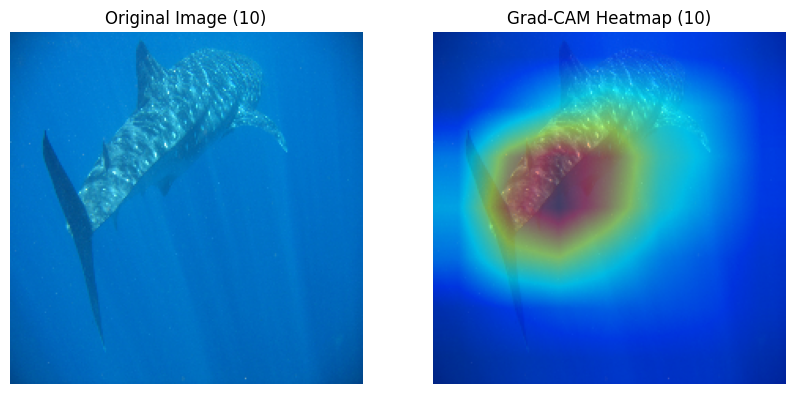


Visualizing Grad-CAM for individual: 26560de1-6930-ddaf-5069-f7b85acd40fb


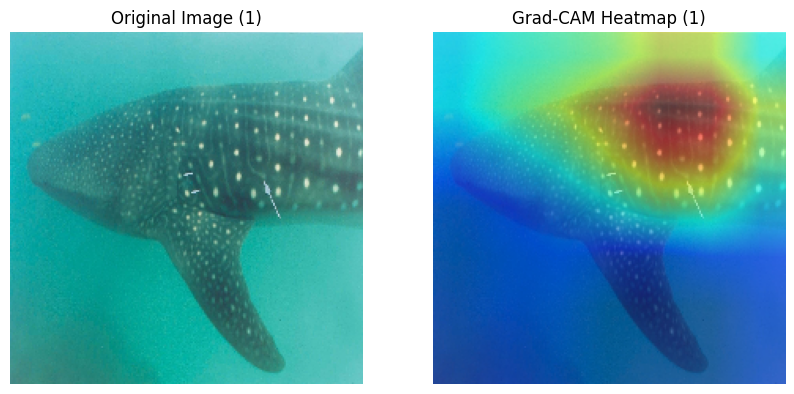

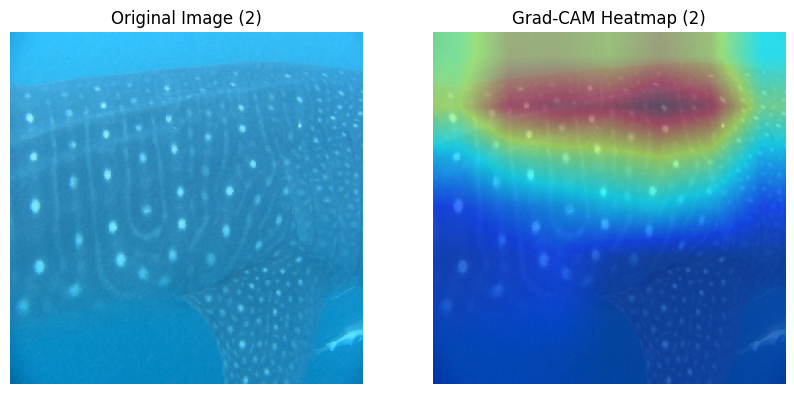

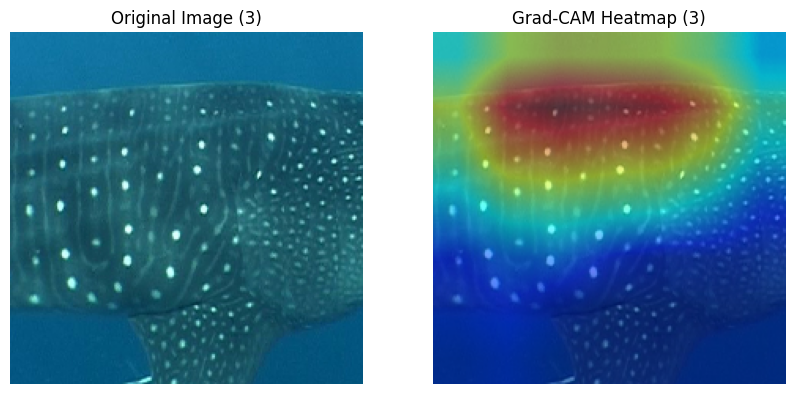

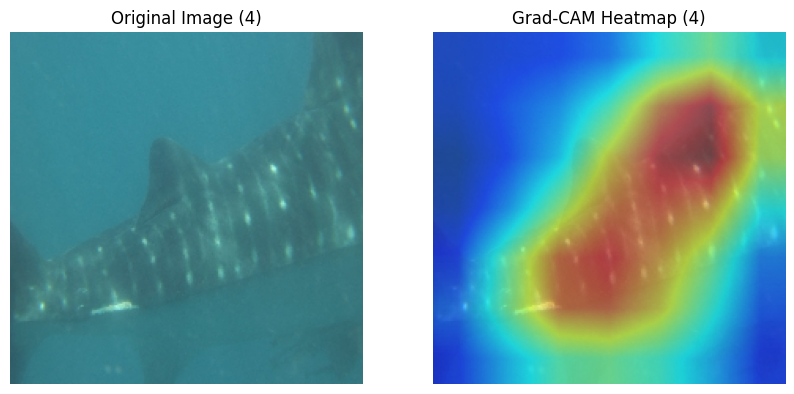

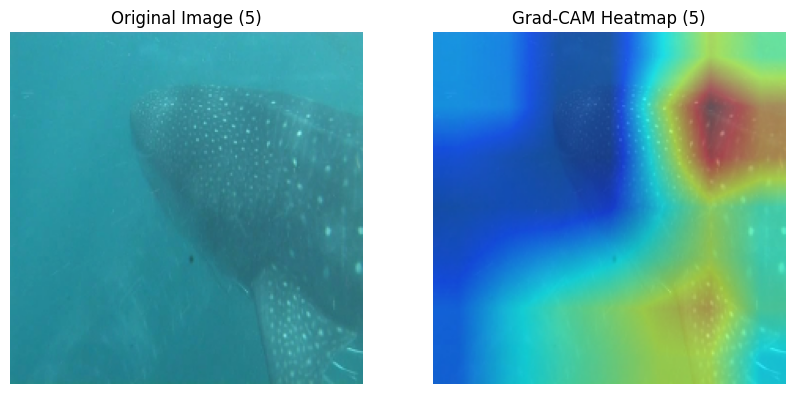

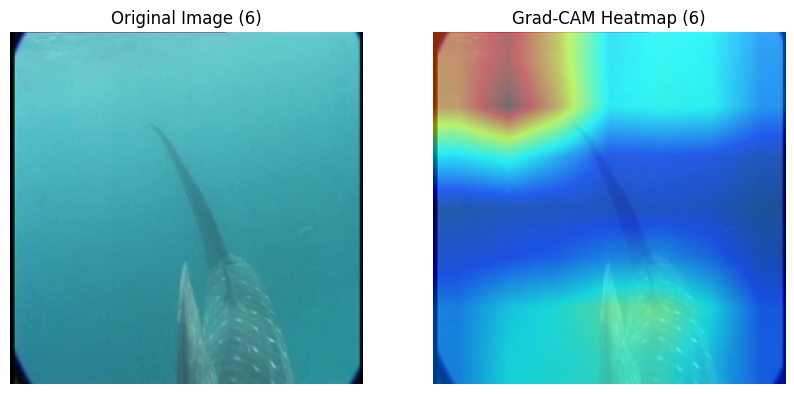

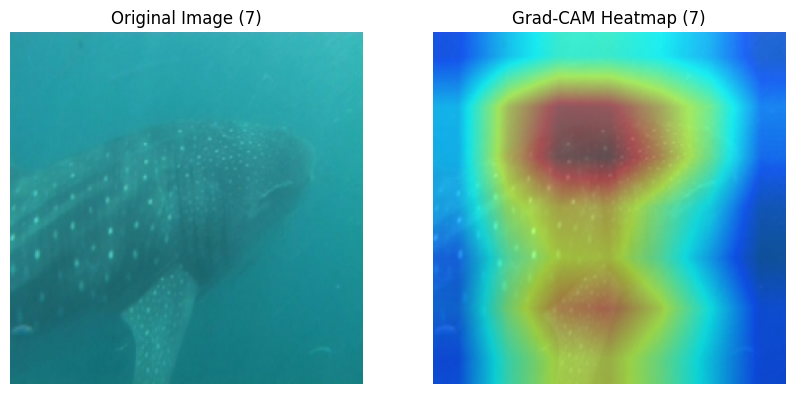

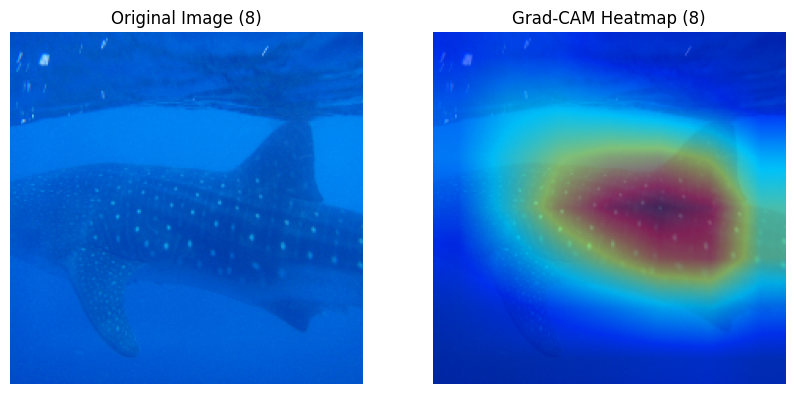

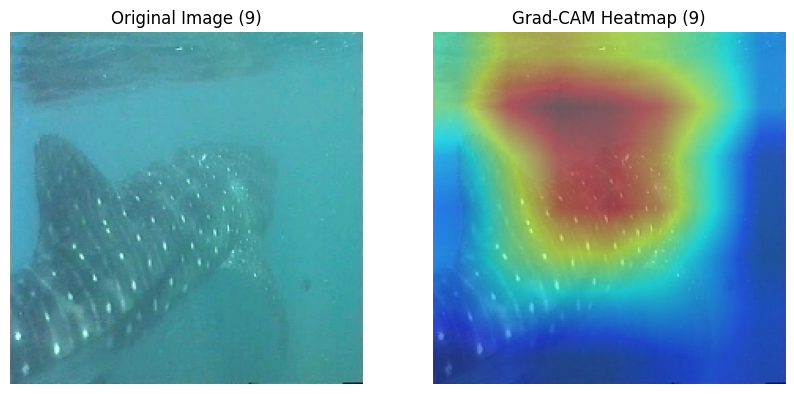

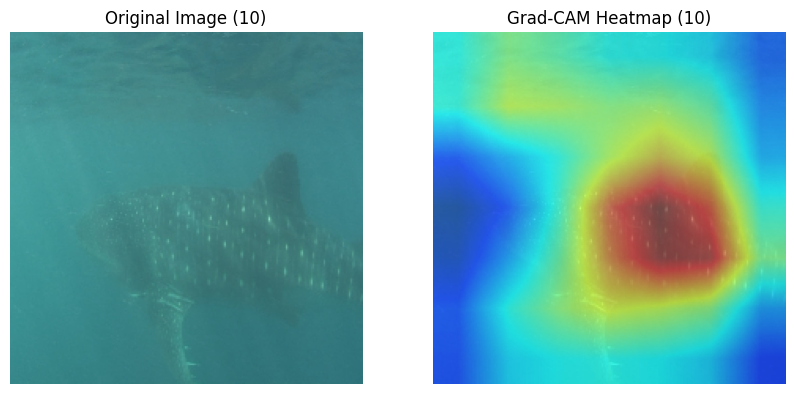

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
target_layers = [model.layer4[-1]]

for i, class_name in enumerate(top_classes):
    print(f"\nVisualizing Grad-CAM for individual: {class_name}")
    # Filter dataset_items for the current class
    class_images = [item for item in dataset_items if item['label'] == i]

    # Limit to 10 images per individual
    for j, item in enumerate(class_images[:10]):
        test_image_path = item['path']

        # Read image for visualization
        img = cv2.imread(test_image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        img_float = np.float32(img) / 255.0

        # Prepare for model
        input_tensor, _ = dataset[dataset_items.index(item)] # Get the correct tensor from dataset
        input_tensor = input_tensor.unsqueeze(0).to(device)

        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor)[0, :]
        visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image ({j+1})")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(visualization)
        plt.title(f"Grad-CAM Heatmap ({j+1})")
        plt.axis('off')
        plt.show()

### Reflecting on Results

Examine the GradCAM overlays carefully before answering these questions:

1. Does GradCAM highlight the whale shark's spot pattern, or does it focus on other image regions such as background water, the boat, or the diver? What does this tell you about what the model has learned?
2. How would you design an experiment to distinguish between a model that learned the spot pattern versus one that learned to recognize correlated background cues such as water color or location?
3. What modifications to the training pipeline (data augmentation, cropping strategy, loss function) might improve the biological meaningfulness of the learned features?
